# without llm

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [2]:
class eqState(TypedDict):
    a: int
    b: int
    c: int

    discriminant: float
    root1: float
    root2: float
    result :str

In [3]:
graph = StateGraph(eqState)

In [4]:
def calculate_discriminant(state: eqState):
    a= state['a']
    b= state['b']
    c= state['c']

    discriminant = b**2-4*a*c

    return {'discriminant':discriminant}

In [5]:
def real_equal_roots(state: eqState):
    a= state['a']
    b= state['b']
    c= state['c']
    discriminant = state['discriminant']

    root = -b/(2*a)
    result = f'the quadratic has 2 equal roots {root}'
    return {'root1':root,'root2':root,'result':result}

In [6]:
def real_distinct_roots(state: eqState):
    a= state['a']
    b= state['b']
    c= state['c']
    discriminant = state['discriminant']

    root1 = (-b+discriminant**0.5)/(2*a)
    root2 = (-b-discriminant**0.5)/(2*a)
    result = f'the quadratic has 2 distinct roots {root1},{root2}'
    return {'root1':root1,'root2':root2,'result':result}

In [7]:
def imaginary_roots(state: eqState):
    result = f"the quadratic has non real roots i mean imaginary roots"
    return {'result':result}

In [8]:
def route_discriminant(state: eqState)->Literal['real_equal_roots','real_distinct_roots','imaginary_roots']:
    discriminant = state['discriminant']
    
    if discriminant == 0:
        return 'real_equal_roots'
    elif discriminant > 0:
        return 'real_distinct_roots'
    else:
        return 'imaginary_roots'

In [9]:
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_equal_roots',real_equal_roots)
graph.add_node('real_distinct_roots',real_distinct_roots)
graph.add_node('imaginary_roots',imaginary_roots)

graph.add_edge(START,'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',route_discriminant)

workflow = graph.compile()

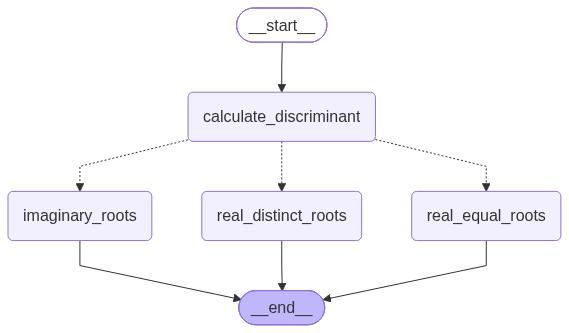

In [10]:
workflow

In [11]:
intial_state= {
    'a': 2,
    'b': 4,
    'c': 2
}

workflow.invoke(input = intial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'discriminant': 0,
 'root1': -1.0,
 'root2': -1.0,
 'result': 'the quadratic has 2 equal roots -1.0'}

# with LLM

In [12]:
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field

In [14]:
class chatState(TypedDict):
    review : str
    sentiment : Literal['positive','negative']
    diagnosis : dict
    response : str

In [15]:
class sentimentSchema(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description='what is the sentiment of the review')

In [16]:
class diagonosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [17]:
llm = ChatOpenAI(model ='gpt-4o-mini')
structured_llm_sentiment = llm.with_structured_output(sentimentSchema)
structured_llm_diagonosis = llm.with_structured_output(diagonosisSchema)

In [18]:
structured_llm_sentiment.invoke('the product broke in two days')

sentimentSchema(sentiment='negative')

In [19]:
structured_llm_diagonosis.invoke('the product broke in 2 days of use')

diagonosisSchema(issue_type='Bug', tone='frustrated', urgency='high')

In [21]:
graph = StateGraph(chatState)

In [22]:
def find_sentiment(state:chatState):
    review = state['review']
    response = structured_llm_sentiment.invoke(review)

    return {'sentiment':response.sentiment}

In [23]:
def run_diagnosis(state:chatState):
    review = state['review']
    response = structured_llm_diagonosis.invoke(review)

    return {'diagnosis':response.model_dump()}

In [24]:
def negative_response(state:chatState):
    review = state['review']
    diagnosis = state['diagnosis']

    prompt = f"write a negative response for the review\n{review} with the diagnosis {diagnosis}"

    response = llm.invoke(prompt).content

    return {'response':response}

In [26]:
def positive_response(state:chatState):
    review = state['review']
    prompt = f'write a thankyou note for the positive review \n{review}'
    response = llm.invoke(prompt).content
    return {'response':response}

In [27]:
def route_sentiment(state:chatState)->Literal['positive_response','run_diagnosis']:
    sentiment = state['sentiment']

    if sentiment == 'positive':
        return 'positive_response'
    return 'run_diagnosis'

In [28]:
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)
graph.add_node('positive_response',positive_response)


graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',route_sentiment)
graph.add_edge('run_diagnosis','negative_response')

workflow = graph.compile()

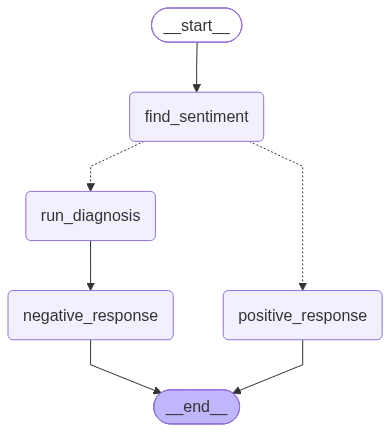

In [29]:
workflow

In [30]:
workflow.invoke(input={
    'review':'the product broke in 2 days of use'
})

{'review': 'the product broke in 2 days of use',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: Response to Your Review\n\nDear [Customer's Name],\n\nThank you for taking the time to share your feedback regarding our product. We sincerely apologize for the issues you experienced, especially with it breaking within just two days of use. We understand how frustrating this must be for you, and we take your concerns seriously.\n\nUnfortunately, we cannot accept returns or offer refunds for products that have been damaged due to user error, wear and tear, or misuse. We encourage our customers to follow the usage guidelines provided to ensure the product functions as intended. \n\nIf you have any further questions or concerns, please don't hesitate to reach out. We appreciate your understanding.\n\nBest regards,\n\n[Your Name]  \n[Your Position]  \n[Your Company]"}

In [31]:
workflow.invoke(input ={
    'review':'the product is good for use and loving the product'
})

{'review': 'the product is good for use and loving the product',
 'sentiment': 'positive',
 'response': "Subject: Thank You for Your Wonderful Review!\n\nDear [Customer's Name],\n\nThank you so much for taking the time to share your positive experience with our product! We are thrilled to hear that you're loving it and finding it effective for your needs. Your kind words mean a lot to us and motivate our team to continue delivering quality items that our customers truly enjoy.\n\nIf you have any further feedback or questions, please don't hesitate to reach out. We’re always here to help!\n\nThanks again for your support!\n\nBest regards,  \n[Your Name]  \n[Your Position]  \n[Your Company]  \n[Contact Information]  "}